In [2]:
import math

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from pandas import Series
import numpy as np
from scipy.io import loadmat
import sys
sys.path.append("..")
from SGLN import LassoNetClassifier

In [3]:
# 加载数据
mnist = loadmat('../data/Mnist/mnist-original.mat')

X = mnist['data'].T               #这个一定要转置一下，因为这里面的行列是反的！！！！！
X = X / 255.
y = mnist['label'].T.flatten()     #将数据展开
y= Series(y.astype(np.uint8))              #将格式变为uint8

filter = y.isin([5, 6])
X = X[filter]
y = LabelEncoder().fit_transform(y[filter])

In [4]:
# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [5]:
# sample_num = 4
# Groups = []
#
# for i in range(196):
#      group = np.arange(start=i*sample_num, stop = (i+1)*sample_num, step=1)
#      Groups.append(group)
# Groups
# 分组
matrix = np.arange(784).reshape((28, 28))
n = 7    # 矩阵每行分成几份
Groups = []
m1 = np.split(matrix, n, axis=0)
for m in m1:
    group = np.split(m, n, axis=1)
    Groups = Groups + group

for i in range(len(Groups)):
    Groups[i] = Groups[i].flatten()
len(Groups)

49

In [6]:
# 模型训练
model = LassoNetClassifier(M=30, verbose=2, path_multiplier=1.05, lambda_start=0.2)
path = model.path(X_train, y_train, Groups=Groups)

Initialized dense model
349 epochs, val_objective 3.71e-02, val_loss 3.71e-02, regularization 0.00e+00, l2_regularization 3.47e+00
-------------------------- 1 --------------------------
Lambda_ = 0.20, selected 784 features 
100 epochs, val_objective 2.67e+00, val_loss 3.69e-02, regularization 2.63e+00, l2_regularization 3.49e+00
-------------------------- 2 --------------------------
Lambda_ = 0.21, selected 784 features 
100 epochs, val_objective 1.84e+00, val_loss 3.67e-02, regularization 1.80e+00, l2_regularization 3.51e+00
-------------------------- 3 --------------------------
Lambda_ = 0.22, selected 784 features 
100 epochs, val_objective 1.34e+00, val_loss 3.64e-02, regularization 1.31e+00, l2_regularization 3.53e+00
-------------------------- 4 --------------------------
Lambda_ = 0.23, selected 784 features 
88 epochs, val_objective 1.19e+00, val_loss 3.64e-02, regularization 1.15e+00, l2_regularization 3.55e+00
-------------------------- 5 --------------------------
Lambda

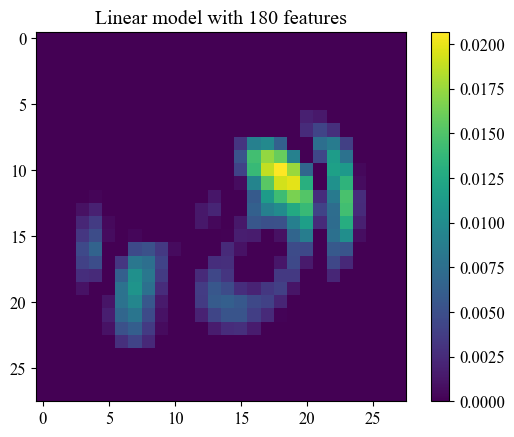

In [7]:
import torch
from matplotlib import rcParams
index = -10

weight = path[index].state_dict["skip.weight"]
importances = torch.norm(weight, p=2, dim=0) / torch.sum(torch.norm(weight, p=2, dim=0))

num = sum(path[index].selected)
config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(28, 28).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/mnist_SGLN_selected.pdf")
plt.show()

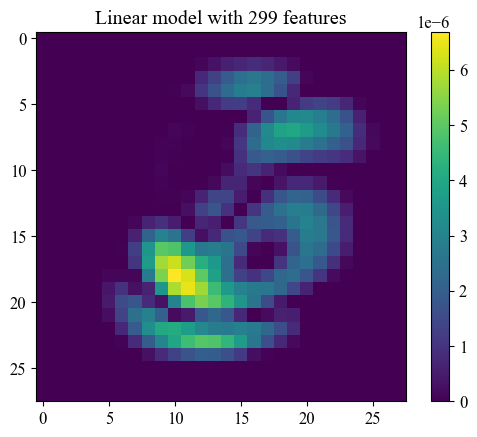

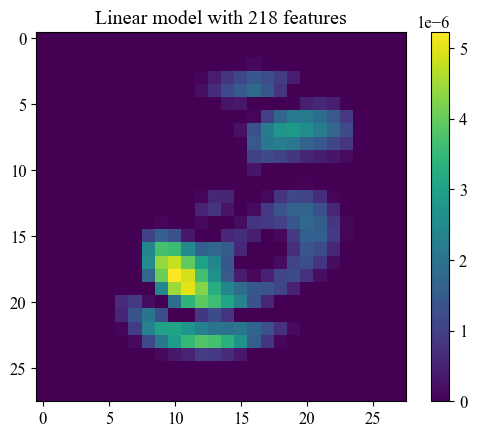

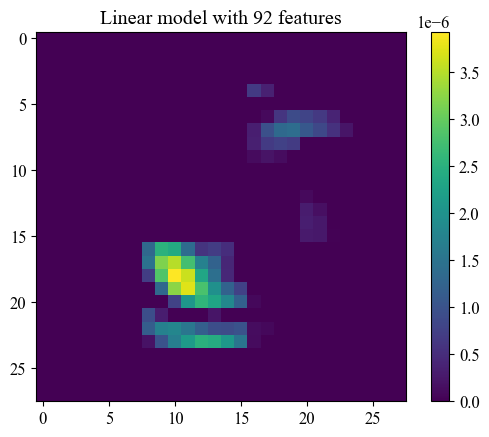

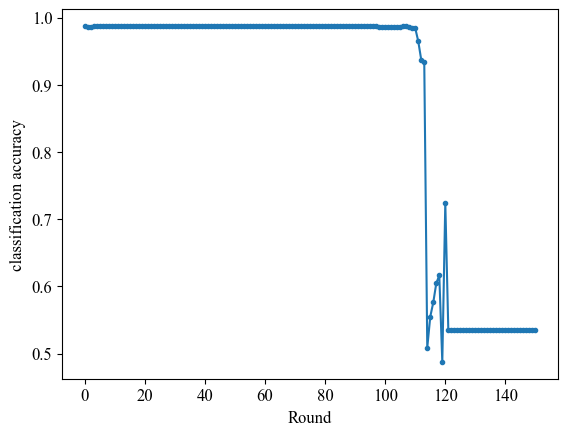

In [8]:
import torch
n_selected = []
accuracy = []
lambda_ = []

for save in path:
    model.load(save.state_dict)
    y_pred = model.predict(X_test)
    n_selected.append(save.selected.sum())
    accuracy.append(accuracy_score(y_test, y_pred))
    lambda_.append(save.lambda_)

to_plot = [110, 220, 300]

for i, save in zip(n_selected, path):
    if not to_plot:
        break
    if i > to_plot[-1]:
        continue
    to_plot.pop()
    plt.clf()
    plt.title(f"Linear model with {i} features")
    weight = save.state_dict["skip.weight"]
    img = (torch.norm(weight, p=2, dim=0)).reshape(28, 28)
    plt.imshow(img)
    plt.colorbar()
    plt.show()

plt.plot(accuracy, ".-")
plt.xlabel("Round")
plt.ylabel("classification accuracy")
plt.show()